<a href="https://colab.research.google.com/github/fischera715/SP_500_Analysis/blob/main/SP_500_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S & P Time Series Analysis

In [ ]:
install.packages("quantmod")
install.packages("ggplot2")
install.packages("tseries")

library(quantmod)
library(ggplot2)
library(tseries)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
getSymbols("^GSPC", src = "yahoo", from = "2020-01-01", to = "2025-12-31")

sp500 <- Ad(GSPC)
head(sp500)

[1] "GSPC"

           GSPC.Adjusted
2020-01-02       3257.85
2020-01-03       3234.85
2020-01-06       3246.28
2020-01-07       3237.18
2020-01-08       3253.05
2020-01-09       3274.70

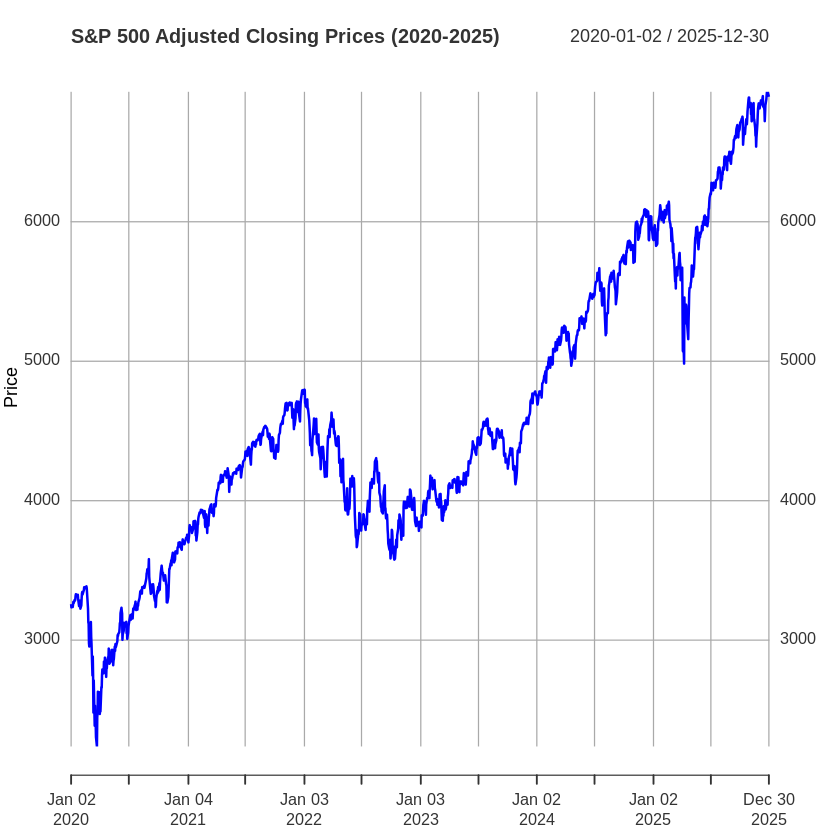

In [ ]:
plot(sp500, main="S&P 500 Adjusted Closing Prices (2020-2025)",
     ylab="Price", xlab="Date", col="blue")

In [ ]:
# Daily log returns: r_t = log(P_t) - log(P_{t-1})
log_returns <- diff(log(Ad(GSPC)))
log_returns <- na.omit(log_returns)

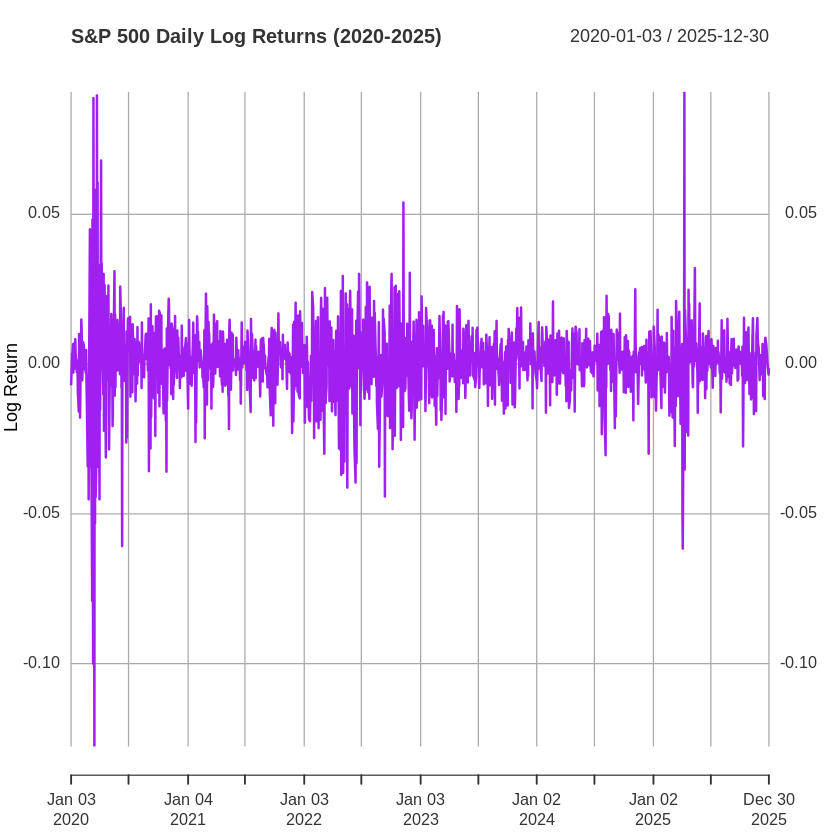

In [ ]:
plot(log_returns, main="S&P 500 Daily Log Returns (2020-2025)",
     ylab="Log Return", xlab="Date", col="purple")

In [ ]:
mean_ret <- mean(log_returns)
var_ret <- var(log_returns)
sd_ret <- sd(log_returns)

cat("Mean of returns:", mean_ret, "\n")
cat("Variance of returns:", var_ret, "\n")
cat("Standard deviation of returns:", sd_ret, "\n")

Mean of returns: 0.0004979475 
Variance of returns: 0.0001748793 
Standard deviation of returns: 0.0132242 


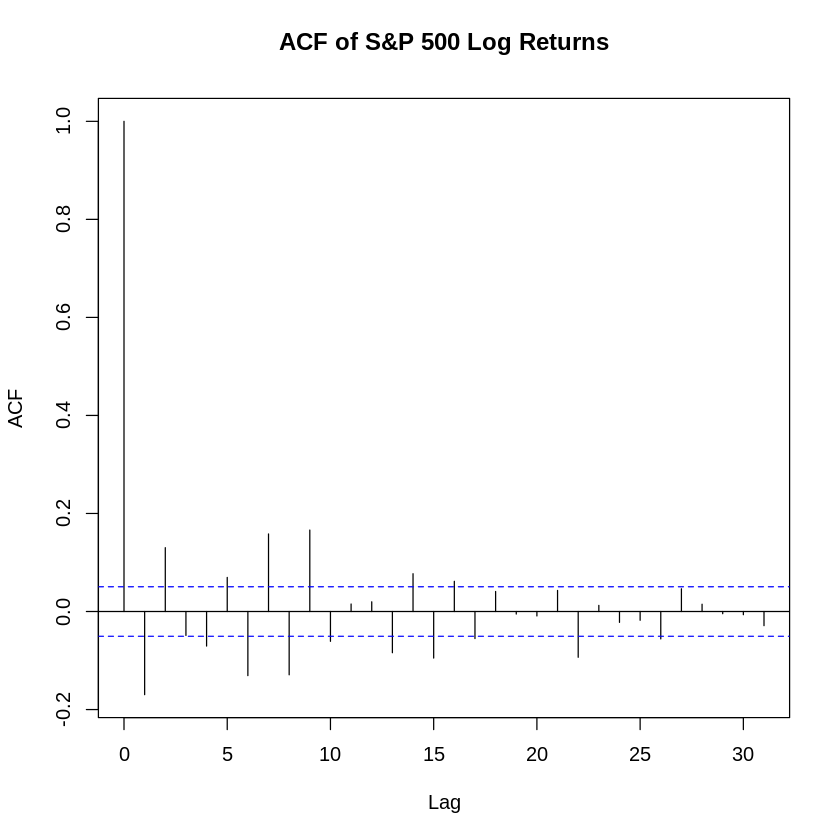

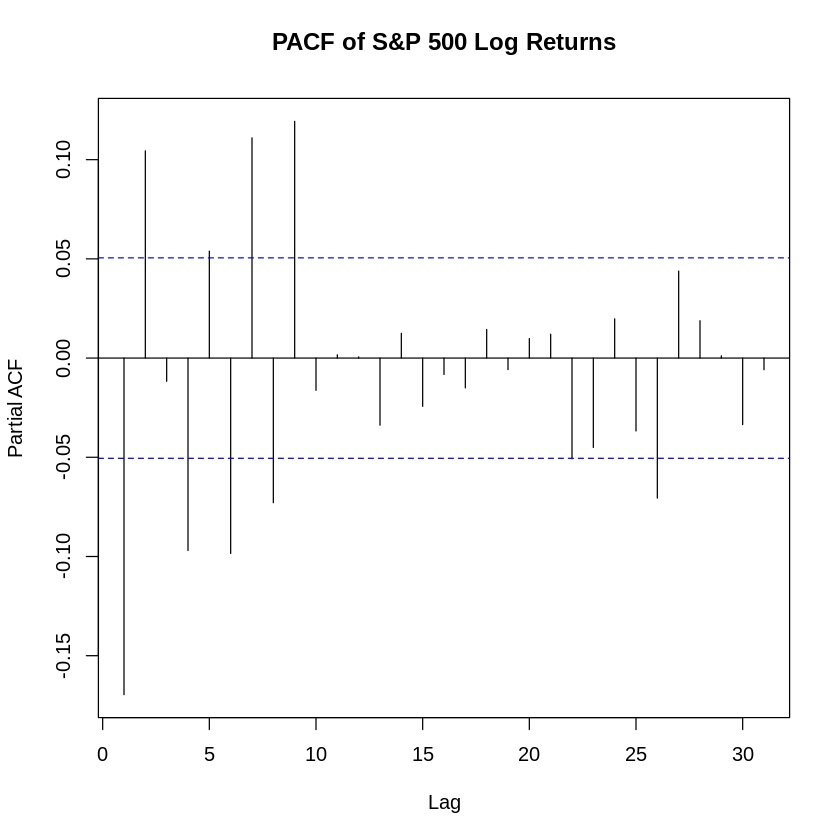

In [ ]:
# Autocorrelation function
acf(log_returns, main="ACF of S&P 500 Log Returns")

pacf(log_returns, main="PACF of S&P 500 Log Returns")

In [ ]:
library(tseries)

adf.test(log_returns)

Warning message in adf.test(log_returns):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  log_returns
Dickey-Fuller = -10.687, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary


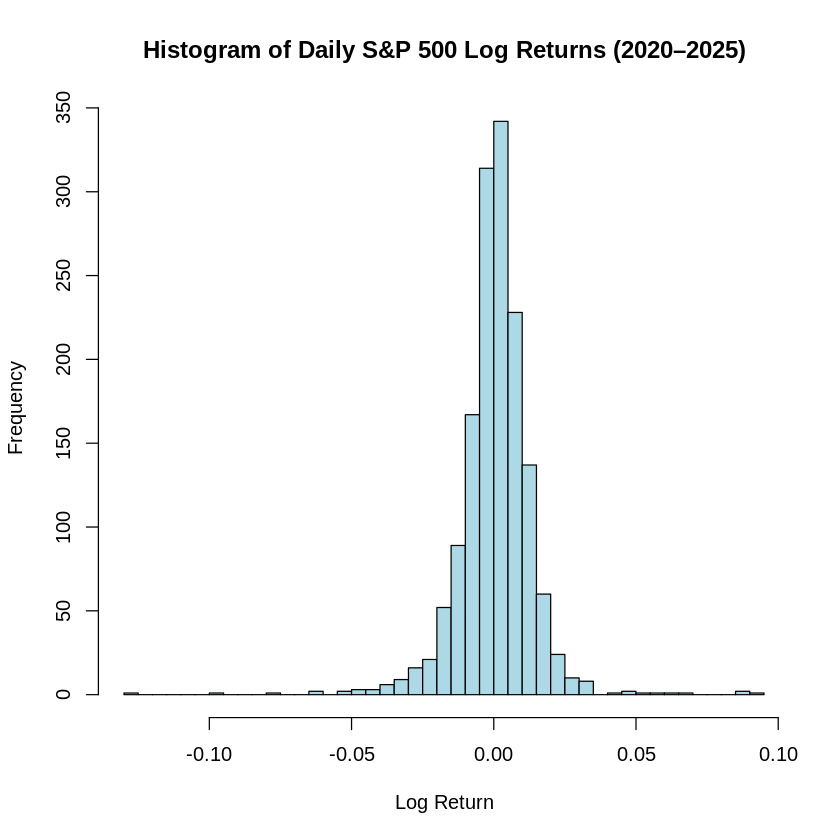

In [ ]:
hist(log_returns, breaks=50, col="lightblue",
     main="Histogram of Daily S&P 500 Log Returns (2020–2025)",
     xlab="Log Return")

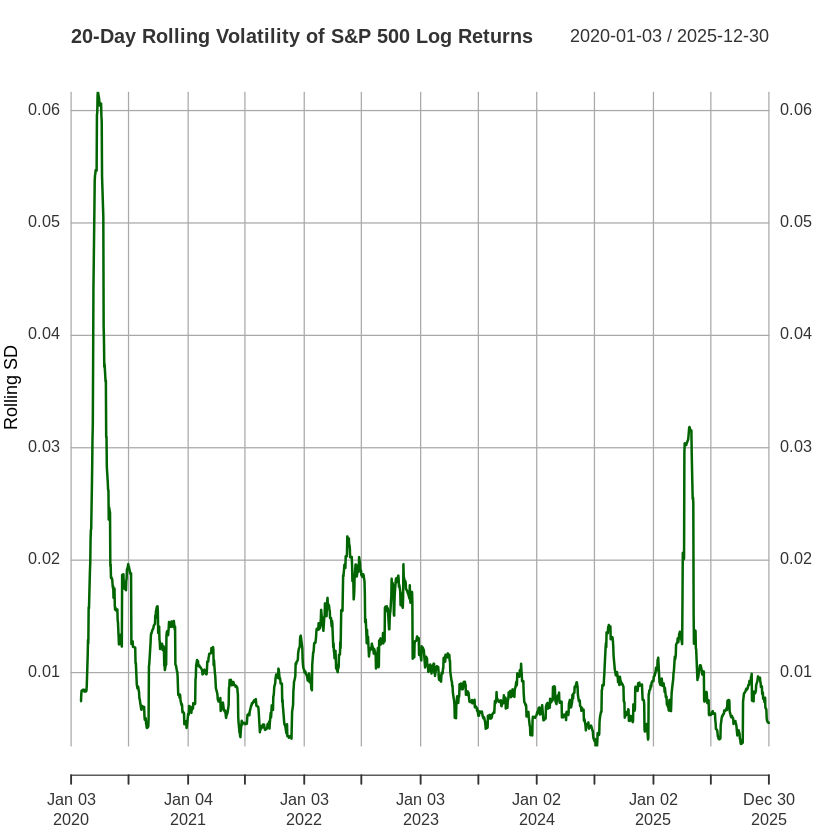

In [ ]:
roll_sd <- rollapply(log_returns, width=20, FUN=sd, by=1, align="right")

plot(roll_sd, main="20-Day Rolling Volatility of S&P 500 Log Returns",
     ylab="Rolling SD", xlab="Date", col="darkgreen")